<a href="https://colab.research.google.com/github/YikeCahya/PCVK_Ganjil_2026/blob/main/Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PRAKTIKUM**

In [3]:
from google.colab import drive
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

In [4]:
drive.mount('/content/drive')
# Path dasar folder citra
IMG_PATH = '/content/drive/MyDrive/Kuliah/PCVK/JS3'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


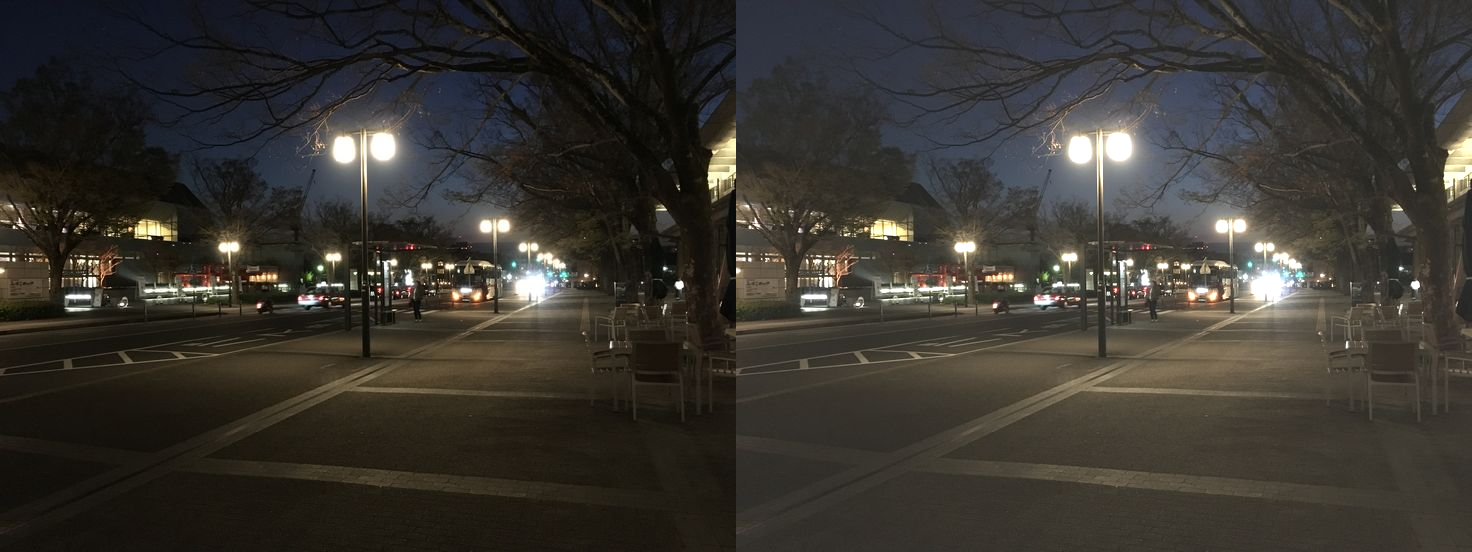

In [6]:
from google.colab.patches import cv2_imshow

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/jalan.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    # Buat kanvas kosong dengan ukuran dan tipe data yang sama
    brightness_image = np.zeros(original.shape, original.dtype)

    # Akses per piksel (baris, kolom, channel)
    # np.clip digunakan untuk truncate nilai agar tetap dalam rentang 0-255
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                val = int(original[y, x, c]) + brightness
                brightness_image[y, x, c] = np.clip(val, 0, 255)

    # Alternatif cepat tanpa for-loop (vektorisasi numpy):
    # brightness_image = np.clip(original.astype(np.int16) + brightness, 0, 255).astype(np.uint8)

    # Gabungkan citra asli dan hasil secara horizontal bersebelahan
    final_frame = cv.hconcat((original, brightness_image))

    # Tampilkan hasil
    cv2_imshow(final_frame)

**TUGAS PRAKTIKUM**

1. Implementasi Inverse Citra

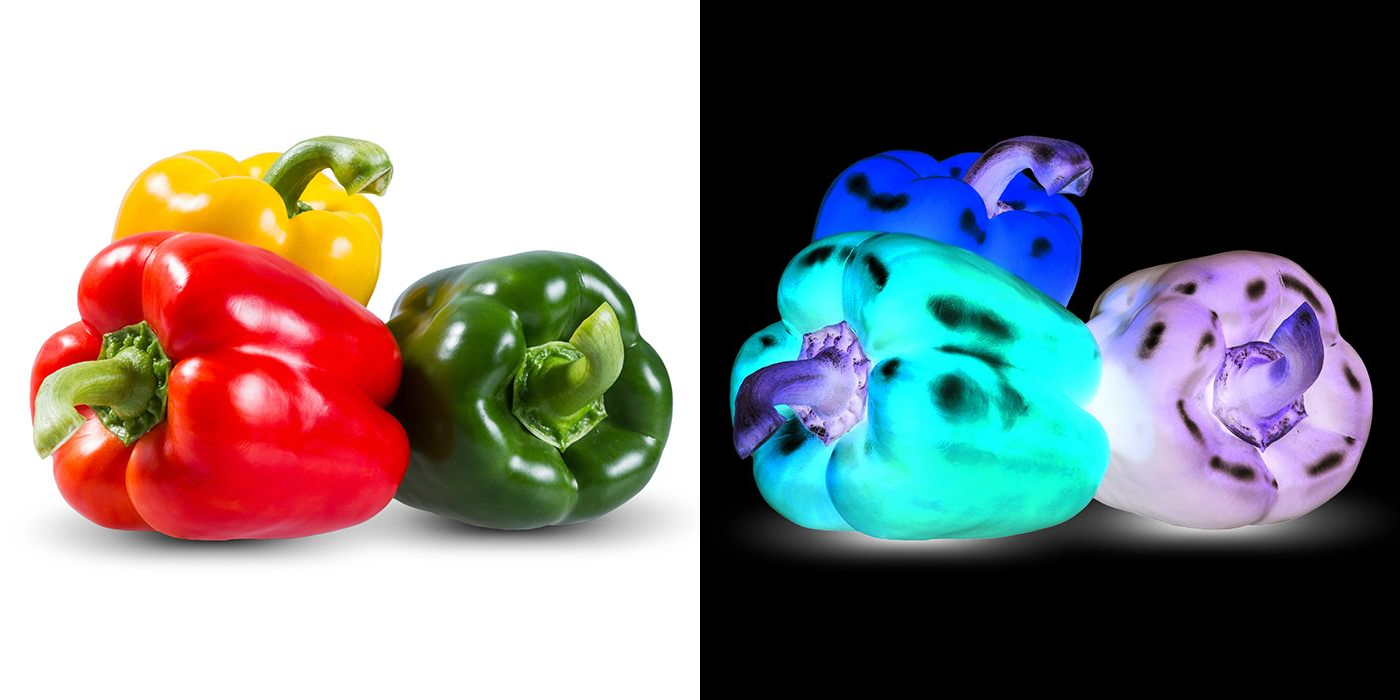

In [7]:
# 1. Baca citra
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/paprika.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    # 2. Operasi inverse citra (vektorisasi numpy langsung)
    inverse_image = 255 - original

    # 3. Gabungkan citra asli dan citra inverse secara berdampingan
    final_frame = cv.hconcat((original, inverse_image))

    # 4. Tampilkan hasil
    cv2_imshow(final_frame)

2. Implementasi Transformasi Contrast

Mengubah kontras dan tingkat kecerahan citra
Masukkan tingkat kecerahan: 20
Masukkan kontras: 5


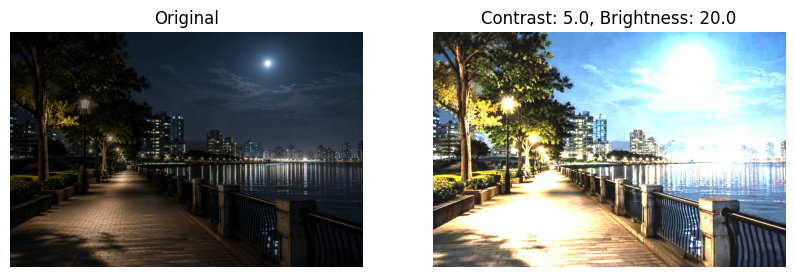

In [11]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/danau.jpg'

# 1. Baca citra
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    # 2. Konversi dari BGR ke RGB untuk ditampilkan via matplotlib
    img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    print("Mengubah kontras dan tingkat kecerahan citra")
    b = float(input("Masukkan tingkat kecerahan: "))
    a = float(input("Masukkan kontras: "))

    # 3. Transformasi kontras dan brightness dengan clipping 0-255
    contrast_img = np.clip(a * img_rgb.astype(np.float32) + b, 0, 255).astype(np.uint8)

    # 4. Tampilkan visualisasi perbandingan
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(contrast_img)
    plt.title(f'Contrast: {a}, Brightness: {b}')
    plt.axis('off')
    plt.show()

3. Transformasi Logarithmic Brightness

Mengubah tingkat kecerahan citra dengan Transformasi Log
Masukkan nilai kecerahan: 50


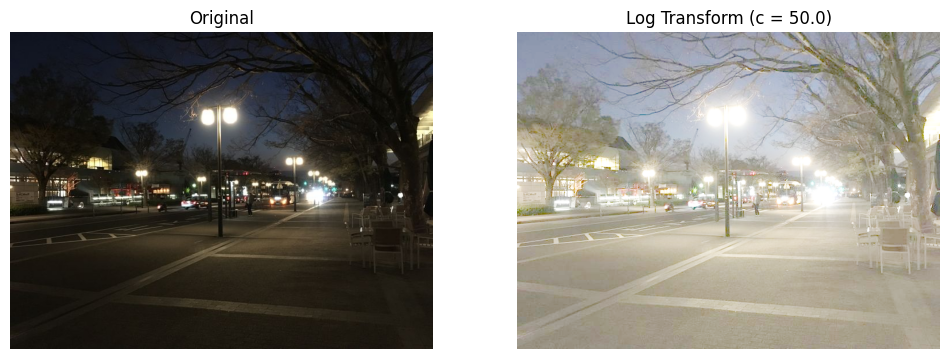

In [17]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/jalan.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    print("Mengubah tingkat kecerahan citra dengan Transformasi Log")
    c = float(input("Masukkan nilai kecerahan: "))

    # Rumus murni modul: s = c * log(1 + r)
    log_img = c * np.log(1.0 + img_rgb.astype(np.float32))

    # Truncate nilai piksel agar tetap di rentang 0 - 255
    log_img = np.clip(log_img, 0, 255).astype(np.uint8)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(log_img)
    plt.title(f'Log Transform (c = {c})')
    plt.axis('off')
    plt.show()

4. Transformasi Grayscale (Averaging, Lightness, Luminance)

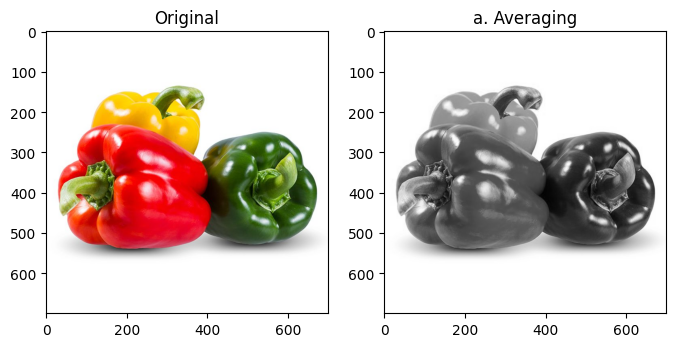

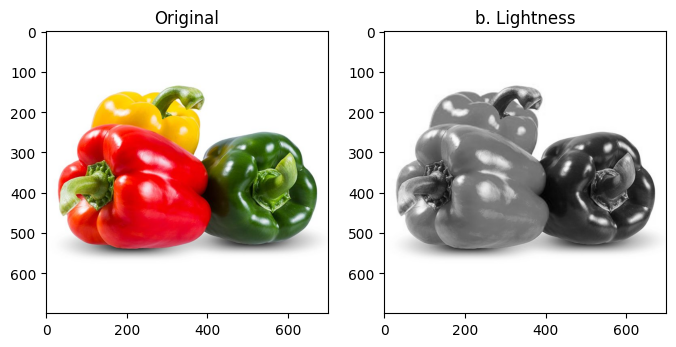

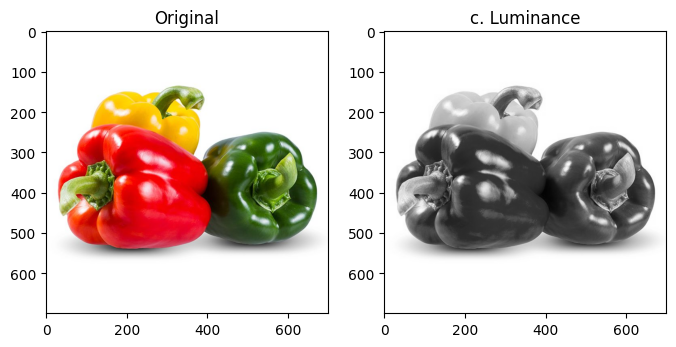

In [18]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/paprika.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    R = img_rgb[:, :, 0].astype(np.float32)
    G = img_rgb[:, :, 1].astype(np.float32)
    B = img_rgb[:, :, 2].astype(np.float32)

    # a. Averaging
    gray_avg = ((R + G + B) / 3.0).astype(np.uint8)

    # b. Lightness
    gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2.0).astype(np.uint8)

    # c. Luminance
    gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

    methods = [('a. Averaging', gray_avg), ('b. Lightness', gray_lightness), ('c. Luminance', gray_luminance)]

    for title, gray_img in methods:
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img_rgb)
        plt.title('Original')

        plt.subplot(1, 2, 2)
        plt.imshow(gray_img, cmap='gray')
        plt.title(title)
        plt.show()

5. Color Splash (Menampilkan Warna Tertentu dan Sisanya Grayscale)

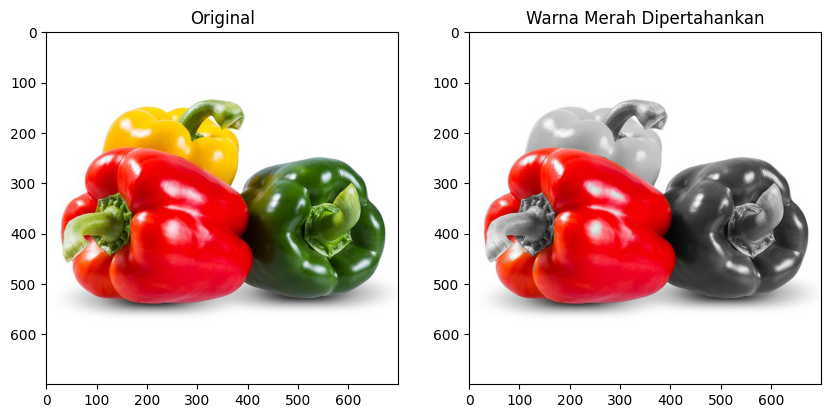

In [19]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/paprika.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)
    img_hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

    # Rentang hue warna merah di HSV
    mask1 = cv.inRange(img_hsv, np.array([0, 70, 50]), np.array([10, 255, 255]))
    mask2 = cv.inRange(img_hsv, np.array([170, 70, 50]), np.array([180, 255, 255]))
    mask_red = mask1 | mask2

    # Buat versi grayscale 3 channel
    gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
    gray_rgb = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

    # Kombinasi: area merah pakai RGB asli, selain itu pakai grayscale
    result = np.where(mask_red[:, :, None] == 255, img_rgb, gray_rgb)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original')

    plt.subplot(1, 2, 2)
    plt.imshow(result)
    plt.title('Warna Merah Dipertahankan')
    plt.show()

6. Gamma Correction

 Gamma Correction pada citra 
------------------------------
Masukkan nilai Gamma: 0.5


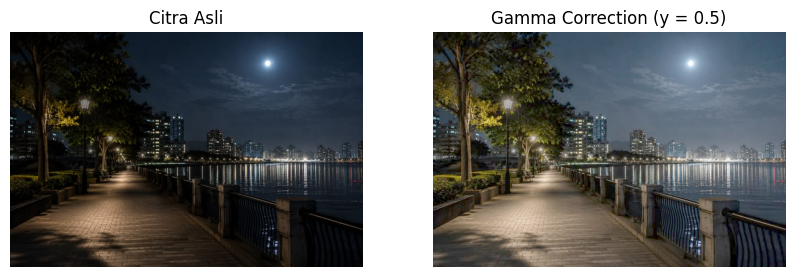

In [25]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/danau.jpg'
original = cv.imread(image_path)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    img_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

    print(' Gamma Correction pada citra ')
    print('------------------------------')
    try:
        gamma = float(input('Masukkan nilai Gamma: '))
    except ValueError:
        print('Error, not a number')
        gamma = 1.0

    # Menggunakan Lookup Table (LUT)
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")
    gamma_corrected = cv.LUT(img_rgb, table)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Citra Asli')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(gamma_corrected)
    plt.title(f'Gamma Correction (y = {gamma})')
    plt.axis('off')
    plt.show()

7. Simulasi Image Bit Depth

Masukkan bit depth tujuan(1 - 8): 3
Bit depth awal: 8 bit
Bit depth tujuan: 3 bit
Jumlah level: 8


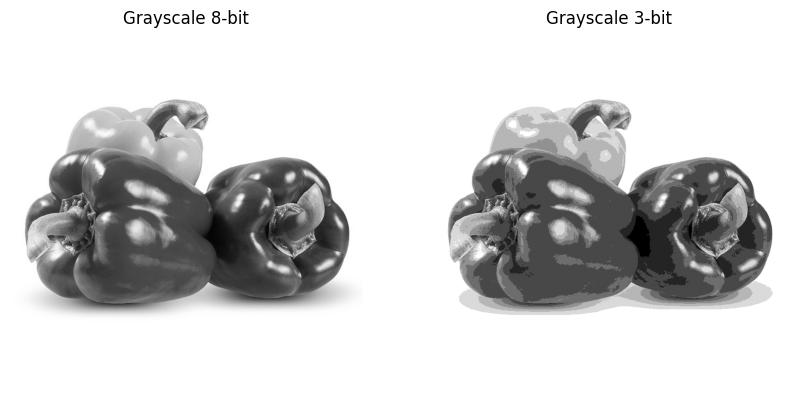

In [29]:
image_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/paprika.jpg'
original = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

if original is None:
    print(f"Error: Gambar tidak ditemukan pada path: {image_path}")
else:
    bit_depth = int(input("Masukkan bit depth tujuan(1 - 8): "))
    level = 255.0 / (pow(2, bit_depth) - 1)

    # Kuantisasi
    depth_image = (np.round(original / level) * level).astype(np.uint8)

    print("Bit depth awal: 8 bit")
    print(f"Bit depth tujuan: {bit_depth} bit")
    print(f"Jumlah level: {2**bit_depth}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Grayscale 8-bit')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'Grayscale {bit_depth}-bit')
    plt.axis('off')
    plt.show()

8. Average Denoising dan Tabel PSNR

---------------------------------------
No  | Jumlah Citra   | Nilai PSNR (dB)
---------------------------------------
1   | 10             | 33.67 dB
2   | 20             | 37.13 dB
3   | 40             | 41.29 dB
4   | 80             | 48.37 dB
5   | 100            | 100.00 dB


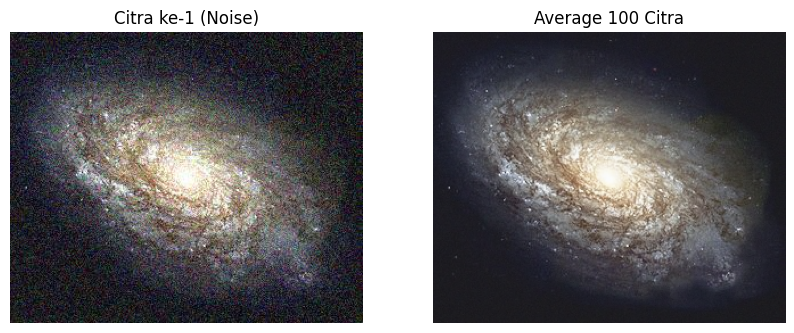

In [34]:
import os
import glob
import math

def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    if mse == 0:
        return 100.0
    return 20 * math.log10(255.0 / math.sqrt(mse))

# 1. Baca citra derau dari folder galaxy
folder_galaxy = '/content/drive/MyDrive/Kuliah/PCVK/JS3/galaxy'
noise_files = glob.glob(f'{folder_galaxy}/*.jpg')

noise_files = sorted(
    noise_files,
    key=lambda x: int(os.path.splitext(os.path.basename(x))[0]) if os.path.splitext(os.path.basename(x))[0].isdigit() else x
)

cv_img = [cv.imread(f) for f in noise_files]

if len(cv_img) > 0:
    # 2. Ambil citra acuan
    ref_path = '/content/drive/MyDrive/Kuliah/PCVK/JS3/galaxy.jpg'
    ref_img = cv.imread(ref_path)

    if ref_img is None:
        ref_img = np.mean(cv_img, axis=0).astype(np.uint8)

    # 3. Hitung dan tampilkan tabel PSNR
    sample_counts = [10, 20, 40, 80, 100]

    print("---------------------------------------")
    print(f"{'No':<3} | {'Jumlah Citra':<14} | {'Nilai PSNR (dB)':<15}")
    print("---------------------------------------")

    for i, count in enumerate(sample_counts, start=1):
        selected = cv_img[:count]
        avg_img = np.mean(selected, axis=0).astype(np.uint8)
        psnr_val = calculate_psnr(ref_img, avg_img)
        print(f"{i:<3} | {count:<14} | {psnr_val:.2f} dB")

    # 4. Tampilkan citra
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv.cvtColor(cv_img[0], cv.COLOR_BGR2RGB))
    plt.title('Citra ke-1 (Noise)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv.cvtColor(avg_img, cv.COLOR_BGR2RGB))
    plt.title('Average 100 Citra')
    plt.axis('off')
    plt.show()

Pertanyaan:
1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
* Tidak selalu. Peningkatan nilai PSNR paling
tajam terjadi pada penambahan jumlah citra di tahap-tahap awal (misalnya dari 10 ke 20 citra, dan 20 ke 40 citra). Seiring bertambahnya citra mendekati 80 hingga 100, laju peningkatan kualitas secara persepsi visual mata manusia mulai melambat (*diminishing returns*) karena sebagian besar derau acak sudah tereliminasi secara efektif sejak jumlah sampel menengah.   
2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?   
* Peningkatan mulai melandai secara visual pada kisaran 40 hingga 50 citra. Pada rentang ini, nilai PSNR sudah melampaui 40 dB, yang mana dalam standar pemrosesan citra digital merepresentasikan kualitas rekonstruksi yang sangat baik dengan sisa derau yang hampir tidak kasat mata.   
3. Apa kesimpulan yang Anda peroleh dari percobaan ini?   
* Derau Gaussian memiliki nilai ekspektasi (rata-rata) sama dengan nol dan terdistribusi secara acak di setiap tangkapan citra.   
* Dengan melakukan operasi rata-rata aritmatika (*pixel averaging*) pada piksel di koordinat yang sama dari kumpulan citra jamak, nilai positif dan negatif dari derau saling meniadakan mendekati nol.   
* Semakin banyak citra yang dirata-ratakan, nilai *Mean Squared Error* (MSE) akan semakin mendekati nol, sehingga nilai PSNR meningkat dan kualitas visual citra menjadi semakin bersih menyerupai citra aslinya.

9. Image Masking Operator Logika

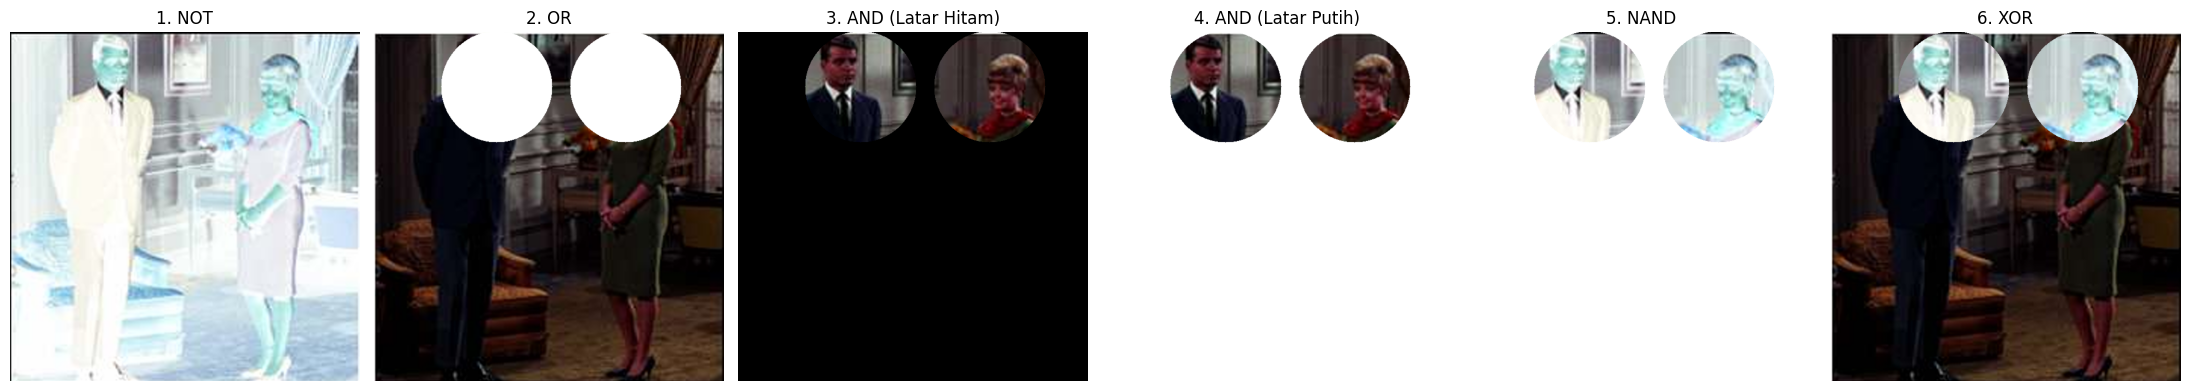

In [51]:
# 1. Baca citra
img_couple = cv.imread('couple.png')

h_c, w_c = img_couple.shape[:2]

# 2. Buat mask 2 lingkaran putih persis di kepala
mask = np.zeros((h_c, w_c), dtype=np.uint8)
r = int(min(h_c, w_c) * 0.16)
center_lelaki = (int(w_c * 0.35), int(h_c * 0.16))
center_wanita = (int(w_c * 0.72), int(h_c * 0.16))

cv.circle(mask, center_lelaki, r, 255, -1)
cv.circle(mask, center_wanita, r, 255, -1)
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

# 3. Operasi logika
res_not = cv.bitwise_not(img_couple)
res_or = cv.bitwise_or(img_couple, mask_3ch)
res_and_black = cv.bitwise_and(img_couple, mask_3ch)  # AND (latar hitam)
not_mask = cv.bitwise_not(mask_3ch)
res_and_white = cv.bitwise_or(res_and_black, not_mask)  # AND (latar putih)
res_nand = cv.bitwise_not(res_and_black)
res_xor = cv.bitwise_xor(img_couple, mask_3ch)

# 4. Tampilkan semua hasil secara berdampingan
operations = [
    ('1. NOT', res_not),
    ('2. OR', res_or),
    ('3. AND (Latar Hitam)', res_and_black),
    ('4. AND (Latar Putih)', res_and_white),
    ('5. NAND', res_nand),
    ('6. XOR', res_xor)
]

plt.figure(figsize=(22, 5))
for idx, (title, img_res) in enumerate(operations, 1):
    plt.subplot(1, 6, idx)
    plt.imshow(cv.cvtColor(img_res, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

Analisis:

Operasi logika biner pada pengolahan citra sangat efektif digunakan untuk segmentasi wilayah minat (*Region of Interest / ROI*), penggabungan beberapa lapisan citra, maupun isolasi objek tertentu tanpa memengaruhi area citra lainnya.

10.  Foto Malam Hari

In [52]:
night_img = cv.imread('foto_malam.jpeg')

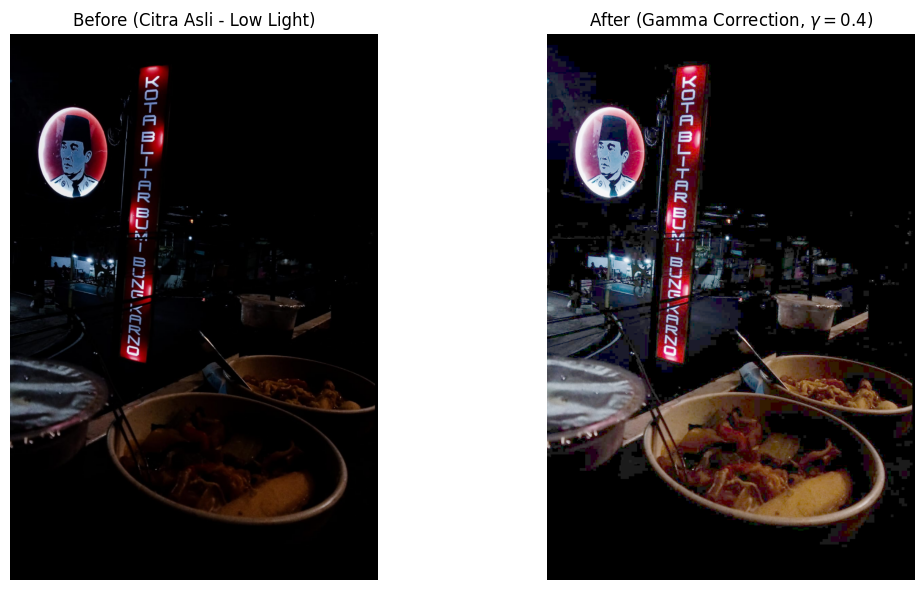

In [61]:
if night_img is None:
    print(f"Error: Gambar tidak ditemukan")
else:
    # Ubah format ke RGB untuk visualisasi Matplotlib
    img_rgb = cv.cvtColor(night_img, cv.COLOR_BGR2RGB)

    # Implementasi Gamma Correction dengan gamma < 1.0 untuk mencerahkan bayangan
    gamma = 0.4
    # Membuat tabel pemetaan (Lookup Table / LUT) untuk efisiensi komputasi
    inv_gamma = gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    enhanced_img = cv.LUT(img_rgb, table)

    # Tampilan
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Before (Citra Asli - Low Light)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(enhanced_img)
    plt.title(rf'After (Gamma Correction, $\gamma={gamma}$)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

**Deskripsi:**
1. Metode yang Dipilih
  * Gamma Correction *(Power-Law Transformation)* dengan nilai $\gamma = 0,5$.   
2. Alasan Pemilihan Metode
  * Distribusi Intensitas Non-linier: Foto malam hari umumnya didominasi oleh piksel gelap (rentang intensitas rendah). Jika menggunakan *Linear Brightness* ($f(x,y) + b$), seluruh piksel dinaikkan secara merata sehingga area yang awalnya sudah terang (seperti lampu jalan) akan mengalami saturasi/pecah (*clipping* ke nilai 255).   
  * Ekspansi Area Gelap: Nilai $\gamma < 1,0$ memetakan rentang nilai input gelap yang sempit menjadi rentang nilai output yang lebih lebar secara melengkung (non-linier). Hal ini membuat detail tekstur bangunan, jalan, dan dedaunan yang tersembunyi dalam kegelapan terangkat jelas tanpa merusak area lampu jalan secara berlebihan.   
3. Risiko Metode yang Digunakan
  * Peningkatan Derau *(Noise Amplification)*: Sensor kamera ponsel atau kamera digital pada kondisi rendah cahaya biasanya meninggalkan derau (sensor noise) pada area bayangan gelap. Mengangkat nilai intensitas gelap secara tajam akan membuat digital grain atau bintik-bintik derau tersebut terlihat makin nyata.   
  * Penurunan Kontras *(Washed Out)*: Jika nilai gamma disetel terlalu kecil (misalnya $\gamma < 0,3$), warna hitam pekat akan menghilang dan berubah menjadi abu-abu pudar sehingga citra tampak seperti berkabut.

11. crayfish

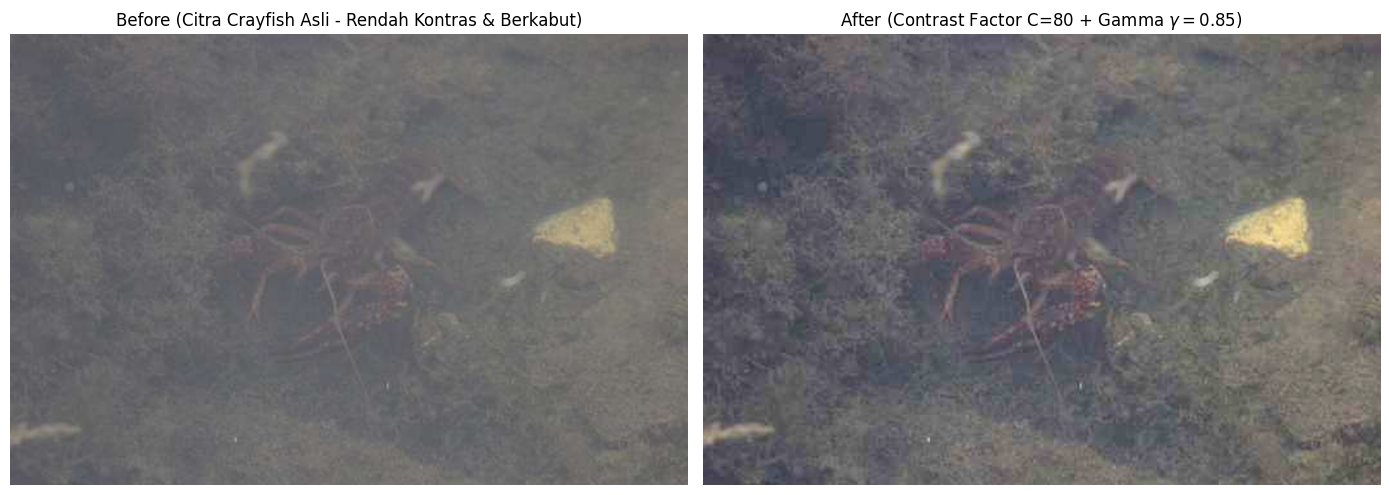

In [60]:
crayfish = cv.imread('kepiting.png')

if crayfish is None:
    print(f"Error: Gambar tidak ditemukan")
else:
    # Konversi ke format RGB
    img_rgb = cv.cvtColor(crayfish, cv.COLOR_BGR2RGB)

    # METODE 1: Peningkatan Kontras menggunakan Contrast Correction Factor
    # C bernilai antara -255 sampai 255 (nilai positif meningkatkan kontras)
    C = 80.0
    factor = (259.0 * (C + 255.0)) / (255.0 * (259.0 - C))
    contrast_img = np.clip(factor * (img_rgb.astype(np.float32) - 128.0) + 128.0, 0, 255).astype(np.uint8)

    # METODE 2: Gamma Correction untuk menyeimbangkan intensitas pencahayaan
    gamma = 0.85
    table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")
    final_img = cv.LUT(contrast_img, table)

    # Visualisasi Before dan After
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Before (Citra Crayfish Asli - Rendah Kontras & Berkabut)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(final_img)
    plt.title(rf'After (Contrast Factor C={int(C)} + Gamma $\gamma={gamma}$)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Metode:
1.   **Contrast Adjustment** menggunakan formula Contrast Correction Factor (F).
2.   **Gamma Correction** non-linier.

Alasan Pemilihan:

1.   Citra kepiting.png diambil di lingkungan bawah air yang keruh, sehingga mengalami hamburan cahaya *(scattering)*. Kondisi ini menyebabkan kurva histogramnya sempit dan terpusat di area abu-abu tengah *(low contrast)*, di mana warna hitam tidak pekat dan warna terang tidak menonjol.
2.   Metode Contrast Correction Factor memusatkan peregangan piksel di sekitar titik tengah (128) sehingga warna gelap ditarik ke arah 0 dan warna terang ditarik ke arah 255 tanpa mengubah nilai rata-rata secara ekstrem.
3. Penambahan Gamma Correction berfungsi sebagai penyeimbang tingkat kecerahan agar tekstur tubuh kepiting tidak terlalu gelap akibat peregangan kontras yang tajam.

Penentuan Parameter Terbaik:
1. Nilai C = 80,0: Memberikan faktor pengali F = 1,88. Angka ini cukup besar untuk memisahkan objek kepiting dari latar belakang dasar pasir/air yang berkabut tanpa menyebabkan saturasi berlebih *(over-clipping)* pada area terang.
2. Nilai $\gamma = 0,85: Nilai sedikit di bawah 1,0 mengangkat detail warna merah dan tekstur capit kepiting yang berada di area bayangan agar tampak lebih tegas dan hidup.

